<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/newversion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Rationale for Sinusoids Supporting the Spectral Framework of Fractional DFTs
Let $\mathbf{G}_{\theta \in \mathbb{Z}}$ be the family  extends the classical harmonic analysis framework of the DFT by introducing a tunable parameter $\theta$

$\begin{equation}
\mathbf{G}_\theta = \left[ w^{\left(k - \frac{\theta}{2}\right)\left(\ell - \frac{\theta}{2}\right)} \right]_{k,\ell=0}^{N-1},
\end{equation}$
$\theta\in\{0,1,\cdots,2N-1\},w = e^{-j \frac{2\pi}{N}}$

$\begin{align*}
\mathbf{G}_\theta^2 &=
\begin{cases}
\mathbf{J}_{\theta + 1} \oplus  (-1)^\theta \mathbf{J}_{N - \theta - 1}  & \text{for } 0 \leq \theta < N, \\[6pt]
 (-1)^\theta \, \mathbf{J}_{\theta - N+ 1} \oplus \mathbf{J}_{2N - \theta - 1}, & \text{for } N \leq \theta < 2N,
\end{cases}\\
\mathbf{G}_\theta^4 &= I,
\end{align*}$

where:

-  $J$ is the antidiagonal matrix,



In [ ]:
import numpy as np
#parameter
N = 7
theta = 4
# Construct matrix G_theta with normalization 1/sqrt(N)
def G_theta(N, theta):
    w = np.exp(-1j * 2 * np.pi / N)
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (1/np.sqrt(N)) * (w ** ((k - theta/2) * (l - theta/2)))

# Construct J_n (matrix with ones on the anti-diagonal)
def J(n):
    J = np.zeros((n, n), dtype=complex)
    for i in range(n):
        J[i, n - 1 - i] = 1
    return J

# Compute G_theta^2 according to the theoretical formula
def G_theta_squared(N, theta):
    if 0 <= theta < N:
        A = J(theta+1)
        B = (-1)**theta * J(N - theta - 1)
    elif N <= theta < 2*N:
        A = (-1)**theta * J(theta - N + 1)
        B = J(2*N - theta - 1)
    else:
        raise ValueError("theta must be between 0 and 2N-1")
    # Block diagonal (direct sum)
    return np.block([
        [A, np.zeros((A.shape[0], B.shape[1]), dtype=complex)],
        [np.zeros((B.shape[0], A.shape[1]), dtype=complex), B]
    ])

if __name__ == "__main__":


    G = G_theta(N, theta)
    G2_direct = G @ G  # matrix multiplication using @
    G2_theory = G_theta_squared(N, theta)

    print("G_theta:")
    print(np.round(G, 3))

    print("\nG_theta^2 (direct multiplication):")
    print(np.round(G2_direct, 3))

    print("\nG_theta^2 (theoretical formula):")
    print(np.round(G2_theory, 3))

    # Test correctness: compare the two results
    error = np.max(np.abs(G2_direct - G2_theory))
    print("\nMax absolute difference between direct and theoretical results:", error)
    if error < 1e-10:
        print("Test PASSED ✅")
    else:
        print("Test FAILED ❌")


G_theta:
[[-0.341+0.164j -0.084-0.368j  0.378+0.j    -0.084+0.368j -0.341-0.164j
   0.236-0.296j  0.236+0.296j]
 [-0.084-0.368j  0.236-0.296j  0.378+0.j     0.236+0.296j -0.084+0.368j
  -0.341+0.164j -0.341-0.164j]
 [ 0.378+0.j     0.378+0.j     0.378+0.j     0.378+0.j     0.378+0.j
   0.378+0.j     0.378+0.j   ]
 [-0.084+0.368j  0.236+0.296j  0.378+0.j     0.236-0.296j -0.084-0.368j
  -0.341-0.164j -0.341+0.164j]
 [-0.341-0.164j -0.084+0.368j  0.378+0.j    -0.084-0.368j -0.341+0.164j
   0.236+0.296j  0.236-0.296j]
 [ 0.236-0.296j -0.341+0.164j  0.378+0.j    -0.341-0.164j  0.236+0.296j
  -0.084-0.368j -0.084+0.368j]
 [ 0.236+0.296j -0.341-0.164j  0.378+0.j    -0.341+0.164j  0.236-0.296j
  -0.084+0.368j -0.084-0.368j]]

G_theta^2 (direct multiplication):
[[ 0.-0.j -0.+0.j -0.-0.j  0.+0.j  1.+0.j  0.-0.j  0.+0.j]
 [-0.+0.j -0.-0.j  0.+0.j  1.+0.j -0.-0.j  0.+0.j -0.-0.j]
 [-0.-0.j  0.+0.j  1.+0.j  0.-0.j  0.+0.j -0.+0.j  0.-0.j]
 [ 0.+0.j  1.+0.j  0.-0.j  0.+0.j -0.+0.j  0.-0.j  0.+0.j]


#Let the parameterized discrete trigonometric transforms be defined as follows:
$\begin{equation}
\mathrm{DCT}_\theta = \frac{2}{\sqrt{N}}
\left[ \cos\!\left((k - \tfrac{\theta}{2})(l - \tfrac{\theta}{2}) \tfrac{2\pi}{N}\right) \right]_{k,l=0}^{N-1},\quad\mathrm{DST}_\theta = \frac{2}{\sqrt{N}}
\left[ \sin\!\left((k - \tfrac{\theta}{2})(l - \tfrac{\theta}{2}) \tfrac{2\pi}{N}\right) \right]_{k,l=0}^{N-1}.
\end{equation}$

Where

\begin{equation}
\begin{cases}
\mathbf{G}_\theta = \frac{1}{2}\left(\mathrm{DCT}_\theta + i\,\mathrm{DST}_\theta \right), \\[4pt]   
\mathrm{DCT}_\theta \cdot \mathrm{DST}_\theta = \mathbf{0},
\end{cases}
\end{equation}

-  Table 2
-  eigenvalues of DCT and DST
-  \begin{equation}
\begin{cases}
\mathrm{DCT}_\theta = \mathbf{G}_\theta^3 + \mathbf{G}_\theta, \\[4pt]   
i\,\mathrm{DST}_\theta = \mathbf{G}_\theta^3 - \mathbf{G}_\theta,
\end{cases}
\end{equation}

-  \begin{equation}
\begin{cases}
\dfrac{1}{2}\,\mathrm{DCT}_\theta^2 = \mathbf{G}_\theta^2 + \mathbf{I},\\  
\dfrac{1}{2}\,\mathrm{DST}_\theta^2 = \mathbf{G}_\theta^2 - \mathbf{I}.
\end{cases}
\end{equation}

In [ ]:
import numpy as np

# Construct DCT_theta
def DCT_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (2/np.sqrt(N)) * np.cos(((k - theta/2) * (l - theta/2)) * 2*np.pi/N)

# Construct DST_theta
def DST_theta(N, theta):
    k = np.arange(N).reshape(-1, 1)
    l = np.arange(N).reshape(1, -1)
    return (2/np.sqrt(N)) * np.sin(((k - theta/2) * (l - theta/2)) * 2*np.pi/N)

# Construct G_theta from DCT and DST
def G_theta(N, theta):
    DCT = DCT_theta(N, theta)
    DST = DST_theta(N, theta)
    return 0.5 * (DCT + 1j * DST)

# Function to print check result with green tick or red cross
def print_check(name, result):
    symbol = '\u2705' if result else '\u274C'
    print(f"{name} passed? {symbol}")

# Example usage
if __name__ == "__main__":
    N = 6
    theta = 3

    # Compute DCT and DST
    DCT = DCT_theta(N, theta)
    DST = DST_theta(N, theta)

    # 1) Check if DCT @ DST is approximately zero
    check1 = DCT @ DST
    print("DCT @ DST (should be close to zero):")
    print(np.round(check1, 10))
    print_check("Check 1", np.allclose(check1, 0, atol=1e-10))

    # 2) Check G_theta = 0.5*(DCT + i*DST)
    G = G_theta(N, theta)
    G_check = 0.5 * (DCT + 1j * DST)
    print_check("Check 2", np.allclose(G, G_check, atol=1e-10))

    # 3) Check G_theta @ expr_plus - expr_plus ~ 0
    expr_plus = 0.25 * (0.5 * (DCT @ DCT) + DCT)
    check3 = G @ expr_plus - expr_plus
    print_check("Check 3", np.allclose(check3, 0, atol=1e-10))

    # 4) Check G_theta @ expr_minus + expr_minus ~ 0
    expr_minus = 0.25 * (0.5 * (DCT @ DCT) - DCT)
    check4 = G @ expr_minus + expr_minus
    print_check("Check 4", np.allclose(check4, 0, atol=1e-10))

    # 5) Check G_theta @ 0.25*(0.5*(DST@DST)-DST) + i*0.25*(0.5*(DST@DST)-DST) ~ 0
    expr_dst_minus = 0.25 * (0.5 * (DST @ DST) - DST)
    check5 = G @ expr_dst_minus + 1j * expr_dst_minus
    print_check("Check 5", np.allclose(check5, 0, atol=1e-10))

    # 6) Check G_theta @ 0.25*(0.5*(DST@DST)+DST) - i*0.25*(0.5*(DST@DST)+DST) ~ 0
    expr_dst_plus = 0.25 * (0.5 * (DST @ DST) + DST)
    check6 = G @ expr_dst_plus - 1j * expr_dst_plus
    print_check("Check 6", np.allclose(check6, 0, atol=1e-10))
    # 7) Eigenvalue spectrum of DCT
    eigvals_DCT = np.unique(np.round(np.linalg.eigvals(DCT).real, decimals=5))
    print("\nEigenvalues of DCT:")
    print(eigvals_DCT)
    print("*" * 40)
    # 7) Eigenvalue spectrum of DST
    eigvals_DST = np.unique(np.round(np.linalg.eigvals(DST).real, decimals=5))
    print("\nEigenvalues of DST:")
    print(eigvals_DST)
    print("*" * 40)
    # 8) Check DCT_theta = G_theta^3 + G_theta
    check_DCT_relation = np.allclose(DCT, G @ G @ G + G, atol=1e-10)
    print_check("Check 8: DCT_theta = G_theta^3 + G_theta", check_DCT_relation)
    # 9) Check i*DST_theta = G_theta^3 - G_theta
    check_DST_relation = np.allclose(1j*DST, G -G @ G @ G, atol=1e-10)
    print_check("Check 9: i*DST_theta = G_theta - G_theta^3", check_DST_relation)
    # 10) Check 0.5*DCT^2 = G^2 + I
    I = np.eye(N)
    check_DCT2_relation = np.allclose(0.5*(DCT @ DCT), G @ G + I, atol=1e-10)
    print_check("Check 10: 0.5*DCT^2 = G^2 + I", check_DCT2_relation)
    # 11) Check 0.5*DST^2 = G^2 - I
    check_DST2_relation = np.allclose(0.5*(DST @ DST),I- G @ G, atol=1e-10)
    print_check("Check 11: 0.5*DST^2 = i - G^2", check_DST2_relation)



DCT @ DST (should be close to zero):
[[-0.  0. -0.  0. -0. -0.]
 [-0. -0.  0.  0.  0.  0.]
 [-0. -0.  0.  0.  0.  0.]
 [-0.  0. -0.  0. -0. -0.]
 [-0.  0. -0.  0.  0.  0.]
 [ 0. -0.  0. -0. -0. -0.]]
Check 1 passed? ✅
Check 2 passed? ✅
Check 3 passed? ✅
Check 4 passed? ✅
Check 5 passed? ✅
Check 6 passed? ✅

Eigenvalues of DCT:
[-2.  0.  2.]
****************************************

Eigenvalues of DST:
[-2. -0.  2.]
****************************************
Check 8: DCT_theta = G_theta^3 + G_theta passed? ✅
Check 9: i*DST_theta = G_theta - G_theta^3 passed? ✅
Check 10: 0.5*DCT^2 = G^2 + I passed? ✅
Check 11: 0.5*DST^2 = i - G^2 passed? ✅


# Let $\theta=0$, then  $G_\theta=F$ denote a discrete Fourier
$F$ be the discrete Fourier transform (DFT) operator, which satisfies the following algebraic properties:

\begin{align*}
F^2 &= 1\oplus J_{n-1}, \\
F^4 &= I,
\end{align*}

where:

-  $J$ is the antidiagonal matrix,
-  $I$ is the identity matrix of appropriate dimension.

In [ ]:
import numpy as np
from numpy.linalg import norm
from scipy.linalg import block_diag

# === Parameters ===
m = 3
N = 4 * m
pi = np.pi
w = np.exp(-2j * pi / N)

# === Construct Identity and Symmetry Matrix ===
I = np.eye(N)
J_N = np.fliplr(np.eye(N, dtype=int))  # Reflection operator
J_N_1 = np.fliplr(np.eye(N - 1, dtype=int))
direct_sum_matrix = block_diag(1, J_N_1)
# === Construct  Matrix ّ ===
F = np.zeros((N, N), dtype=complex)
for k in range(N):
    F[k] = np.sqrt(1 / N) * np.array([
        w ** ((k ) * (l )) for l in range(N)
    ])

# === Matrix Powers ===
F2 = np.linalg.matrix_power(F, 2)
F4 = np.linalg.matrix_power(F, 4)
F3 = np.linalg.matrix_power(F,3)
F_H = np.conj(F).T
# === Identity Verification ===
print("\n--- Algebraic Identity Checks ---")

if np.allclose(F2, direct_sum_matrix, atol=1e-10):
    print("✅ F² = direct_sum_matrix")
else:
    print("❌ F² ≠ direct_sum_matrix")

if np.allclose(F3, F_H, atol=1e-10):
    print("✅ F³ = F_H confirmed")
else:
    print("❌ F³ ≠ F_H")

if np.allclose(F4, I, atol=1e-10):
    print("✅ F⁴ = I confirmed")
else:
    print("❌ F⁴ ≠ I")

print("----------------------------------\n")




--- Algebraic Identity Checks ---
✅ F² = direct_sum_matrix
✅ F³ = F_H confirmed
✅ F⁴ = I confirmed
----------------------------------



In [ ]:
C = np.zeros_like(F)
S = np.zeros_like(F)

# === Construct C and S ===
for k in range(N):
    C[k] = (2 / np.sqrt(N)) * np.array([
        np.cos((k * l * 2 * np.pi) / N) for l in range(N)
    ])
    S[k] = (2 / np.sqrt(N)) * np.array([
        np.sin((k * l * 2 * np.pi) / N) for l in range(N)
    ])
# === Check the connection between C and F ===

print("\n--- C Connection Analysis ---")
if np.allclose(C, F3 + F, atol=1e-10):
    print("✅ C = F3 + F confirmed")
else:
    print("❌ C ≠ F3 + F")

# === Part 1: C Squared Identity ===
Square_C = C @ C

print("\n--- C Analysis ---")
if np.allclose(Square_C, 2 * (I + F2), atol=1e-10):
    print("✅ C² = 2·(I + F2) confirmed")
else:
    print("❌ C² ≠ 2·(I + F2)")

# Eigenvalue spectrum of C
eigvals_C = np.unique(np.round(np.linalg.eigvals(C), decimals=5))
print(f"Eigenvalues of C: {eigvals_C}")
print("*" * 40)


# === Check the connection between S and F ===

print("\n--- S Connection Analysis ---")
if np.allclose(S, 1j * (F - F3), atol=1e-10):
    print("✅ S = 1j * (F - F3) confirmed")
else:
    print("❌ S ≠ 1j * (F - F3)")


# === Part 2: S Squared Identity ===
Square_S = S @ S

print("\n--- S Analysis ---")
if np.allclose(Square_S, 2 * (I - F2), atol=1e-10):
    print("✅ S² = 2·(I - F2) confirmed")
else:
    print("❌ S² ≠ 2·(I + F2)")

# Eigenvalue spectrum of S
eigvals_S = np.unique(np.round(np.linalg.eigvals(S), decimals=5))
print(f"Eigenvalues of S: {eigvals_S}")
print("*" * 40)





--- C Connection Analysis ---
✅ C = F3 + F confirmed

--- C Analysis ---
✅ C² = 2·(I + F2) confirmed
Eigenvalues of C: [-2.+0.j  0.+0.j  2.+0.j]
****************************************

--- S Connection Analysis ---
✅ S = 1j * (F - F3) confirmed

--- S Analysis ---
✅ S² = 2·(I - F2) confirmed
Eigenvalues of S: [-2.+0.j -0.+0.j  2.+0.j]
****************************************


In [ ]:
# === Verify algebraic decomposition of F ===
check1 = np.round(F3 + F - C, 2)
check2 = np.round((1j * (F - F3)) - S, 2)

zero_matrix = np.zeros_like(F)
print("\n--- Decomposition Verification ---")
if np.allclose(check1, zero_matrix) and np.allclose(check2, zero_matrix):
    print("✅ F3 + F = C and 1j * (F - F3) = S confirmed")
else:
    print("❌ Decomposition mismatch detected")
print("----------------------------------")

# === Construct eigenspace components ===
Eig_pos1 = (I + direct_sum_matrix) + C       # eigval +1
Eig_neg1 = (I + direct_sum_matrix) - C       # eigval -1
Eig_posi = (I - direct_sum_matrix) - S       # eigval +i
Eig_negi = (I - direct_sum_matrix) + S       # eigval -i

# === Verify eigenvalue equations Fv = λv ===
print("\n--- Eigenvalue Verification ---")
def check_eigvec(eig_matrix, expected, label):
    if np.allclose(F @ eig_matrix, expected * eig_matrix, atol=1e-2):
        print(f"✅ EigVecs confirmed for eigenvalue {label}")
    else:
        print(f"❌ EigVecs failed for eigenvalue {label}")

check_eigvec(Eig_pos1,  1,   "+1")
check_eigvec(Eig_neg1, -1,   "-1")
check_eigvec(Eig_posi,  1j,  "+i")
check_eigvec(Eig_negi, -1j,  "-i")
print("----------------------------------")

# === Construct normalized projection matrices ===
Proj_pos1 = (1/4) * Eig_pos1
Proj_neg1 = (1/4) * Eig_neg1
Proj_posi = (1/4) * Eig_posi
Proj_negi = (1/4) * Eig_negi

# === Check idempotence: P^2 = P ===
print("\n--- Idempotence Checks for Projectors ---")
def check_idempotent(P, label):
    if np.allclose(P @ P, P, atol=1e-2):
        print(f"✅ Proj_{{{label}}} is idempotent")
    else:
        print(f"❌ Proj_{{{label}}} is not idempotent")

check_idempotent(Proj_pos1, "+1")
check_idempotent(Proj_neg1, "-1")
check_idempotent(Proj_posi, "+i")
check_idempotent(Proj_negi, "-i")
print("------------------------------------------\n")

# === Final identity decomposition check ===
identity_operator = Proj_pos1 + Proj_neg1 + Proj_posi + Proj_negi

print("\n--- Identity Decomposition Check ---")
if np.allclose(np.eye(N), identity_operator, atol=1e-2):
    print("✅ I = Proj_{+1} + Proj_{-1} + Proj_{+i} + Proj_{-i} confirmed")
else:
    print("❌ Identity cannot be decomposed into spectral projections")
print("------------------------------------------")



--- Decomposition Verification ---
✅ F3 + F = C and 1j * (F - F3) = S confirmed
----------------------------------

--- Eigenvalue Verification ---
✅ EigVecs confirmed for eigenvalue +1
✅ EigVecs confirmed for eigenvalue -1
✅ EigVecs confirmed for eigenvalue +i
✅ EigVecs confirmed for eigenvalue -i
----------------------------------

--- Idempotence Checks for Projectors ---
✅ Proj_{+1} is idempotent
✅ Proj_{-1} is idempotent
✅ Proj_{+i} is idempotent
✅ Proj_{-i} is idempotent
------------------------------------------


--- Identity Decomposition Check ---
✅ I = Proj_{+1} + Proj_{-1} + Proj_{+i} + Proj_{-i} confirmed
------------------------------------------


In [ ]:
#==== Selected Columns ====#
patr1_F1 = ((I + direct_sum_matrix) + C) [: , 0: m - 1]
patr2_F1 = ((I + direct_sum_matrix) + C) [: , 2*m][:, np.newaxis]

Eig_F_neg1 = ((I + direct_sum_matrix) - C) [ : , 0: m - 1]

Eig_F_posi = ((I - direct_sum_matrix) - S) [: , 1:m-1]

part1_F_negi = ((I - direct_sum_matrix) + S) [ : , 1:m-1]
part2_F_negi = ((I - direct_sum_matrix) + S) [ : , 2*m-1][:, np.newaxis]
# === merged columns === #
Eig_F1 = np.hstack([patr1_F1, patr2_F1])
Eig_F_negi = np.hstack([part1_F_negi,part2_F_negi])

print("\n\033[94m--- Eigenvector Checks for F ---\033[0m")

# === Check F·v = λ·v for each set ===
if np.allclose(F @ Eig_F1, Eig_F1, atol=1e-2):
    print("✅ Eig_F1 is an eigenbasis of F for λ = +1")
else:
    print("❌ Eig_F1 is not an eigenbasis for λ = +1")

if np.allclose(F @ Eig_F_neg1, -Eig_F_neg1, atol=1e-2):
    print("✅ Eig_F_neg1 is an eigenbasis of F for λ = -1")
else:
    print("❌ Eig_F_neg1 is not an eigenbasis for λ = -1")

if np.allclose(F @ Eig_F_posi, 1j * Eig_F_posi, atol=1e-2):
    print("✅ Eig_F_posi is an eigenbasis of F for λ = +i")
else:
    print("❌ Eig_F_posi is not an eigenbasis for λ = +i")

if np.allclose(F @ Eig_F_negi, -1j * Eig_F_negi, atol=1e-2):
    print("✅ Eig_F_negi is an eigenbasis of F for λ = -i")
else:
    print("❌ Eig_F_negi is not an eigenbasis for λ = -i")

print("\033[90m" + "-"*45 + "\033[0m")





--- Eigenvector Checks for F ---
✅ Eig_F1 is an eigenbasis of F for λ = +1
✅ Eig_F_neg1 is an eigenbasis of F for λ = -1
✅ Eig_F_posi is an eigenbasis of F for λ = +i
✅ Eig_F_negi is an eigenbasis of F for λ = -i
---------------------------------------------


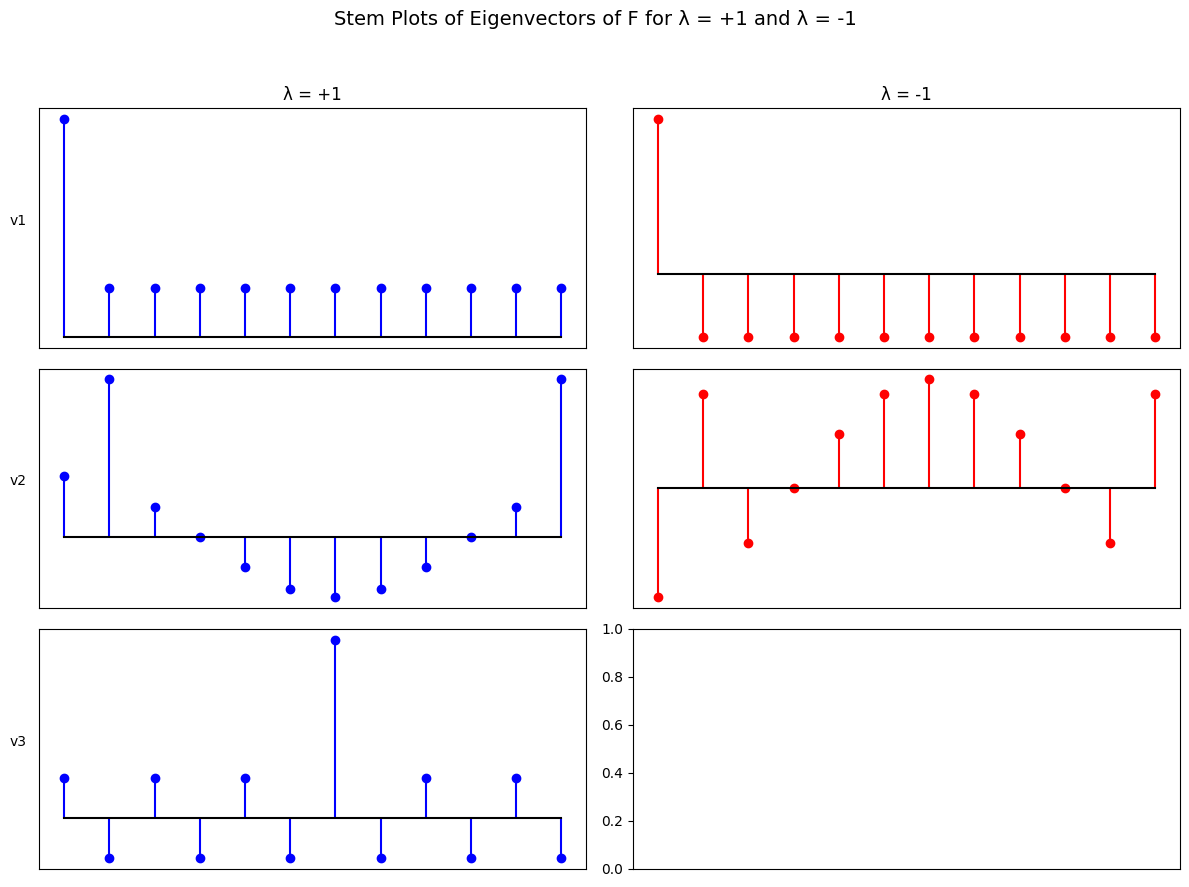

In [ ]:
import matplotlib.pyplot as plt

# Get the number of eigenvectors for λ=+1 and λ=-1
num_vectors_pos1 = Eig_F1.shape[1]
num_vectors_neg1 = Eig_F_neg1.shape[1]

# Create the x-axis values based on the size of each eigenvector
x = np.arange(Eig_F1.shape[0])

# Determine the maximum number of eigenvectors to set the number of rows
max_rows = max(num_vectors_pos1, num_vectors_neg1)

# Create subplots with max_rows rows and 2 columns
fig, axs = plt.subplots(nrows=max_rows, ncols=2, figsize=(12, 3 * max_rows), sharex=True)

# Set a main title for the entire plot
fig.suptitle("Stem Plots of Eigenvectors of F for λ = +1 and λ = -1", fontsize=14)

# Loop over the eigenvectors for λ=+1 and plot them
for i in range(num_vectors_pos1):
    axs[i, 0].stem(x, np.real(Eig_F1[:, i]), linefmt='b-', markerfmt='bo', basefmt='k-')
    axs[i, 0].set_ylabel(f"v{i+1}", rotation=0, labelpad=15)  # y-axis label for each
    axs[i, 0].set_xticks([])  # Remove x-axis ticks for clarity
    axs[i, 0].set_yticks([])  # Remove y-axis ticks for clarity
    axs[i, 0].grid(True)  # Enable grid for better visualization

# Loop over the eigenvectors for λ=-1 and plot them
for i in range(num_vectors_neg1):
    axs[i, 1].stem(x, np.real(Eig_F_neg1[:, i]), linefmt='r-', markerfmt='ro', basefmt='k-')
    axs[i, 1].set_xticks([])  # Remove x-axis ticks
    axs[i, 1].set_yticks([])  # Remove y-axis ticks
    axs[i, 1].grid(True)  # Enable grid

# Set titles for the top row of each column if vectors exist
if num_vectors_pos1 > 0:
    axs[0, 0].set_title("λ = +1", fontsize=12)
if num_vectors_neg1 > 0:
    axs[0, 1].set_title("λ = -1", fontsize=12)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the plot
plt.show()

# Block Forms of C_teta and S_teta for Even-Length Signals
# The Square of C_teta and S_teta
# Eigvals of  C_teta and S_teta
# Even Case

In [ ]:
# Step 1: Build full Ct matrix
import numpy as np

m = 2
N = 4 * m

# Initialize matrix
Ct = np.zeros((N, N))
St = np.zeros((N, N))


# Fill matrix
for k in range(N):
    for l in range(N):
        Ct[k, l] = (2 / np.sqrt(N)) * np.cos((k) * (l) * (2 * np.pi / N))
for k in range(N):
    for l in range(N):
        St[k, l] = (2 / np.sqrt(N)) * np.sin((k) * (l) * (2 * np.pi / N))

print(np.linalg.eigvals(Ct))

# Print result
#print("Ct matrix:")
#print(np.round(Ct, 6))
#print("St matrix:")
#print(np.round(St, 6))

[-2.00000000e+00 -2.00000000e+00  2.00000000e+00  2.00000000e+00
  2.00000000e+00 -1.29911566e-15  7.62053778e-16  2.16905382e-15]


#block form and check

In [ ]:
import numpy as np

m = 2
N = 4 * m

# Step 0: identity and flip matrices
I = np.eye(2*m-1)
J = np.fliplr(np.eye(2*m-1, dtype=int))
# Step 1: Build Cstar and trim
k = np.arange(0, 2*m + 1).reshape(-1, 1)
l = np.arange(0, 2*m + 1).reshape(1, -1)
d = np.ones(2*m + 1, dtype=float)
d[0] = d[-1] = 1/np.sqrt(2)
D = np.outer(d, d)
Cstar = (2 / np.sqrt(N)) * D * np.cos((2 * np.pi / N) * (k * l))
print(np.round(Cstar @ Cstar, 6))
Cstar_trimmed = Cstar[1:-1, 1:-1]

# Step 2: Build recon_C and recon_S
recon_C = np.zeros((N, N))
recon_S = np.zeros((N, N))

val = 2 / np.sqrt(N)
mid = m  # middle index

# First row/col
recon_C[0, :] = val
recon_C[:, 0] = val

# Insert Ck_trimmed into quadrants
recon_C[1:2*m, 1:2*m] = Cstar_trimmed
recon_C[1:2*m, 2*m+1:4*m] = Cstar_trimmed @ J
recon_C[2*m+1:4*m, 1:2*m] = J @ Cstar_trimmed
recon_C[2*m+1:4*m, 2*m+1:4*m] = J @ Cstar_trimmed @ J

#insert blockof recon_S
Sstar=St[1:2*m, 1:2*m]
recon_S[1:2*m, 1:2*m] = Sstar
recon_S[1:2*m,2*m+1:4*m]= -Sstar @ J
recon_S[2*m+1:4*m,1:2*m] =- J @ Sstar
recon_S[2*m+1:4*m,2*m+1:4*m] =J @ Sstar @ J

# Fill middle row and column (after trimming) with ±val
recon_C[mid+2, :] = val * (-1) ** np.arange(N)  # middle row
recon_C[:, mid+2] = val * (-1) ** np.arange(N)  # middle column

# Print final matrix
#print("Shape of recon_C:", recon_C.shape)
#print("Final recon_C:")
#print(np.round(recon_C, 6))

# Check difference with original Ct and St
difference = recon_C - Ct
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_C and Ct:", max_diff)

if np.allclose(recon_C, Ct, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")

difference = recon_S - St
max_diff = np.max(np.abs(difference))
print("\nMaximum absolute difference between recon_S and St:", max_diff)

if np.allclose(recon_S, St, atol=1e-10):
    print("All entries match ✅")
else:
    print("Entries do NOT match ❌")


[[ 1.  0. -0.  0. -0.]
 [ 0.  1.  0. -0. -0.]
 [-0.  0.  1. -0. -0.]
 [ 0. -0. -0.  1. -0.]
 [-0. -0. -0. -0.  1.]]

Maximum absolute difference between recon_C and Ct: 1.9984014443252818e-15
All entries match ✅

Maximum absolute difference between recon_S and St: 1.9984014443252818e-15
All entries match ✅


In [ ]:
# === Compute squares of C_even and S_even ===
Cstar_squared = Cstar @ Cstar
Sstar_squared = Sstar @ Sstar

print("Is C_even^2 ≈ I ?")
print(np.allclose(Cstar_squared, np.eye(Cstar.shape[0]), atol=1e-2))

print("Is S_even^2 ≈ I ?")
print(np.allclose(Sstar_squared, np.eye(Sstar.shape[0]), atol=1e-2))


# === Compute eigenvalues ===
eigvals_Cstar = np.unique(np.round(np.linalg.eigvals(Cstar), 4))
eigvals_Sstar = np.unique(np.round(np.linalg.eigvals(Sstar), 4))

print("Eigenvalues of Cstar (Ct):")
print(eigvals_Cstar)
print("\nEigenvalues of Sstar (St):")
print(eigvals_Sstar)
print("*" * 40)

Is C_even^2 ≈ I ?
True
Is S_even^2 ≈ I ?
True
Eigenvalues of Cstar (Ct):
[-1.  1.]

Eigenvalues of Sstar (St):
[-1.  1.]
****************************************


#Verification and Construction of Eigenbases for $Cstar$ and $Ct$ coressponded to +1 and +2

In [ ]:
# === Perturb Cstar and Sstar by ± identity ===
perturbed_C_plus1   = Cstar + np.eye(Cstar.shape[0])
perturbed_C_minus1  = Cstar - np.eye(Cstar.shape[0])
perturbed_S_plus1   = Sstar + np.eye(Sstar.shape[0])
perturbed_S_minus1  = Sstar - np.eye(Sstar.shape[0])

# === Extract candidate eigenvectors for λ = ±1 ===
part1_eigvecs_C_plus1 = perturbed_C_plus1[:, 0: m - 1]
part2_eigvecs_C_plus1 = perturbed_C_plus1[:, -1][:, np.newaxis]   # last column
eigvecs_C_plus1 = np.hstack([part1_eigvecs_C_plus1, part2_eigvecs_C_plus1])

eigvecs_C_minus1 = perturbed_C_minus1[:, 0: m - 1]

eigvecs_S_plus1 = perturbed_S_plus1[:, 1:m-1]

part1_eigvecs_S_minus1 = perturbed_S_minus1[:, 1:m-1]
part2_eigvecs_S_minus1 = perturbed_S_minus1[:, -1][:, np.newaxis]  # last column
eigvecs_S_minus1 = np.hstack([part1_eigvecs_S_minus1, part2_eigvecs_S_minus1])

# === Check eigenvectors for Cstar ===
print("\033[94m# ======= Check eigenvalue ±1: Cstar  =====#\033[0m")
if np.allclose(Cstar @ eigvecs_C_plus1 - eigvecs_C_plus1, 0):
    print("✅ eigvecs_C_plus1: Eigenbasis for λ=1 of Cstar ")
else:
    print("⚠️ eigvecs_C_plus1: Not an eigenbasis for λ=1 of Cstar ")

if np.allclose(Cstar @ eigvecs_C_minus1 + eigvecs_C_minus1, 0):
    print("✅ eigvecs_C_minus1: Eigenbasis for λ=-1 of Cstar ")
else:
    print("⚠️ eigvecs_C_minus1: Not an eigenbasis for λ=-1 of Cstar ")

# === Check eigenvectors for Sstar  ===
print("\033[94m# ======= Check eigenvalue ±1: Sstar  =====#\033[0m")
if np.allclose(Sstar @ eigvecs_S_plus1 - eigvecs_S_plus1, 0):
    print("✅ eigvecs_S_plus1: Eigenbasis for λ=1 of S_even")
else:
    print("⚠️ eigvecs_S_plus1: Not an eigenbasis for λ=1 of Sstar ")

if np.allclose(Sstar @ eigvecs_S_minus1 + eigvecs_S_minus1, 0):
    print("✅ eigvecs_S_minus1: Eigenbasis for λ=-1 of Sstar ")
else:
    print("⚠️ eigvecs_S_minus1: Not an eigenbasis for λ=-1 of Sstar ")


# === Extend eigenvectors to full domain for FrDCT and FrDST ===
V= eigvecs_C_plus1[1:-1, :]
v0 = eigvecs_C_plus1[0,:]
vm = eigvecs_C_plus1[-1,:]
ext_eigvecs_C_plus2   = np.vstack([np.sqrt(2)*v0,V,np.sqrt(2)*vm,])
ext_eigvecs_C_minus2  = np.vstack([eigvecs_C_minus1, -J_m @ eigvecs_C_minus1])
ext_eigvecs_S_plus2   = np.vstack([eigvecs_S_plus1,   J_m @ eigvecs_S_plus1])
ext_eigvecs_S_minus2  = np.vstack([eigvecs_S_minus1,  J_m @ eigvecs_S_minus1])


# ======= Check eigenvalue ±1: Cstar  =====#
✅ eigvecs_C_plus1: Eigenbasis for λ=1 of Cstar 
✅ eigvecs_C_minus1: Eigenbasis for λ=-1 of Cstar 
# ======= Check eigenvalue ±1: Sstar  =====#
✅ eigvecs_S_plus1: Eigenbasis for λ=1 of S_even
✅ eigvecs_S_minus1: Eigenbasis for λ=-1 of Sstar 
